In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
import numpy as np
import sympy as sp
import torch
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
import matplotlib.pyplot as plt
import time
from Input_Output_Rxn_Networks.ReactionSequenceGenerator import map_indices_to_reactions

In [3]:
# Construct an Input/Output CRN: 4 species, 9 reactions
S_R = np.array([[0, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 1, 0, 1, 2], [1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0]], dtype=np.int8)
S_P = np.array([[1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0, 0, 0], [1, 0, 0, 0, 1, 0, 0, 2, 0], [0, 0, 0, 0, 0, 1, 0, 0, 1]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = 10; theta = 0.61; eta = 0.1; p1=17.17; p2 = 3.44
params = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta, p1, p2], dtype=np.float32)
I = np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=np.int8)
O = np.array([2], dtype=np.int8)
IOCRN = IOCRN_MassAction(S_R, S_P, params, I, O)

In [4]:
# Print the Input/Output CRN
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN.print_reactions(species, inputs)

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612u
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 0.6100000143051147
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 8: X_2 -> 2 Z_1 ; Rate Constant: 17.170000076293945
Reaction 9: 2 X_2 -> Z_2 ; Rate Constant: 3.440000057220459


In [5]:
# Print the ODEs of the Input/Output CRN
params_sym = sp.symbols('k, k_1, gamma_1, gamma_2, mu, theta, eta, p1, p2')
species_sym = sp.symbols('x_1, x_2, z_1, z_2')
inputs_sym = [sp.symbols('u')]
IOCRN.print_ODEs(species_sym, params_sym, inputs_sym)

⎡           -γ₁⋅x₁ + k⋅z₁           ⎤
⎢                                   ⎥
⎢                                  2⎥
⎢-γ₂⋅u⋅x₂ + k₁⋅x₁ - p₁⋅x₂ - 2⋅p₂⋅x₂ ⎥
⎢                                   ⎥
⎢      -η⋅z₁⋅z₂ + μ + 2⋅p₁⋅x₂       ⎥
⎢                                   ⎥
⎢                     2             ⎥
⎣     -η⋅z₁⋅z₂ + p₂⋅x₂  + θ⋅x₂      ⎦


Matrix([
[                           -gamma_1*x_1 + k*z_1],
[-gamma_2*u*x_2 + k_1*x_1 - p1*x_2 - 2*p2*x_2**2],
[                   -eta*z_1*z_2 + mu + 2*p1*x_2],
[           -eta*z_1*z_2 + p2*x_2**2 + theta*x_2]])

In [6]:
# Linearize
A, B = IOCRN.linearize_ODEs(species_sym, params_sym, inputs_sym)
sp.pprint(A)
sp.pprint(B)

⎡-γ₁           0              k      0  ⎤
⎢                                       ⎥
⎢k₁   -γ₂⋅u - p₁ - 4⋅p₂⋅x₂    0      0  ⎥
⎢                                       ⎥
⎢ 0           2⋅p₁          -η⋅z₂  -η⋅z₁⎥
⎢                                       ⎥
⎣ 0       2⋅p₂⋅x₂ + θ       -η⋅z₂  -η⋅z₁⎦
⎡  0   ⎤
⎢      ⎥
⎢-γ₂⋅x₂⎥
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎣  0   ⎦


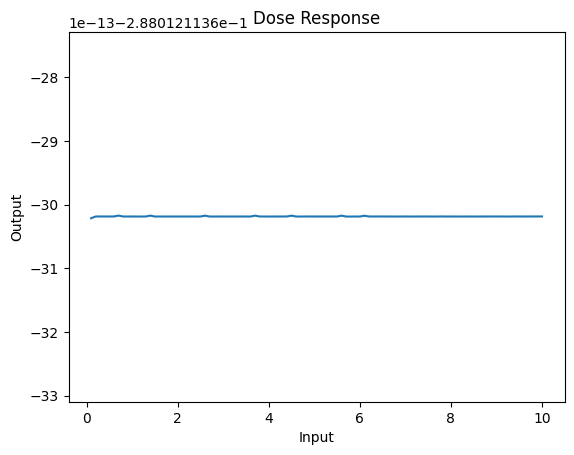

In [7]:
#  Dose Response
N_u = 100
u_array = np.linspace(0.1, 10, N_u, dtype=np.float32)
initial_guess = np.array([0.1, 0.1, 0.1, 0.1], dtype=np.float32)
y_array = IOCRN.dose_response(u_array, initial_guess, True)

Simulation Time: 0.04


Text(0.5, 1.0, 'Transient Response')

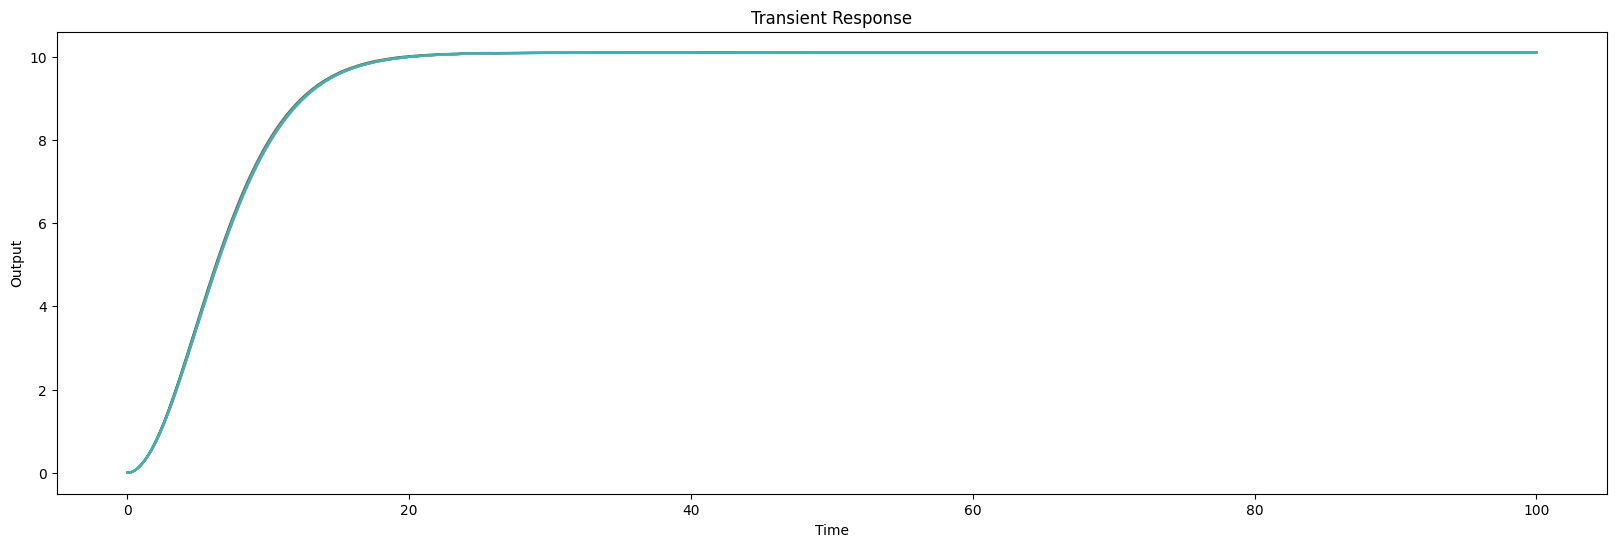

In [8]:
# Transient Response
N_u = 10
u_array = np.linspace(0.1, 10, N_u, dtype=np.float32)
initial_guess = np.array([0.1, 0.1, 0.1, 0.1], dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, 100, 1000, dtype=np.float32)

tic = time.time()
outputs_transient, states_transient = IOCRN.transient_response(u_array, initial_condition, time_horizon, return_states=True)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

outputs_ss = IOCRN.dose_response(u_array, initial_guess, False)

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
for i in range(len(outputs_transient)):
    plt.plot(time_horizon, outputs_transient[i])
    # plt.plot(time_horizon[-1], outputs_ss[i], 'ro')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')
# plt.subplot(1, 2, 2)
# plt.plot(u_array, outputs_ss)
# plt.xlabel('Input')
# plt.ylabel('Output')
# plt.title('Dose Response')
# plt.show()

# Plot the states
# plt.figure(figsize=(20, 6))
# for i in range(len(states_transient)):
#     plt.plot(time_horizon, states_transient[:,i])
# plt.xlabel('Time')
# plt.ylabel('State')
# plt.title('Transient Response')
# plt.show()


In [9]:
# Build bimolecular chemical reaction networks from indices
num_samples = 2
num_species = 5
num_reactions = 12
num_inputs = 2
parameters = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)
species = ['X1', 'X2', 'X3', 'X4', 'X5']
inputs = ['u1', 'u2']
indices = torch.zeros(num_samples, 3, num_reactions).long()
# First sample
indices[0, 0, :] = torch.tensor([0, 6, 4, 4, 5, 7,17, 1, 2, 3, 4, 5])
indices[0, 1, :] = torch.tensor([1, 4, 6, 5,14, 3, 3, 0, 0, 0, 0, 0])
indices[0, 2, :] = torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2])
# Second sample
indices[1, 0, :] = torch.tensor([0, 6, 20, 4, 5, 18,13, 1, 2, 3, 4, 5])
indices[1, 1, :] = torch.tensor([1, 20, 6, 19,14, 3, 12, 0, 0, 0, 0, 0])
indices[1, 2, :] = torch.tensor([1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2])
# Map the indices to the reactions
S_R, S_P, S_I = map_indices_to_reactions(indices, num_samples, num_species, num_reactions, num_inputs)
IOCRN_0 = IOCRN_MassAction(S_R[0], S_P[0], parameters, S_I[0], [3])
IOCRN_1 = IOCRN_MassAction(S_R[1], S_P[1], parameters, S_I[1], [3])
print('Sample 1:')  
IOCRN_0.print_reactions(species, inputs)
print('Sample 2:')  
IOCRN_1.print_reactions(species, inputs)

Sample 1:
Inputs: ['u1', 'u2']
Species: ['X1', 'X2', 'X3', 'X4', 'X5']
Output Species: ['X3']
Reaction 1: 0 -> X1 ; Rate Constant: 1.0u1
Reaction 2: 2 X1 -> X4 ; Rate Constant: 1.0
Reaction 3: X4 -> 2 X1 ; Rate Constant: 1.0
Reaction 4: X4 -> X5 ; Rate Constant: 1.0
Reaction 5: X5 -> X2 + X5 ; Rate Constant: 1.0
Reaction 6: X1 + X2 -> X3 ; Rate Constant: 1.0
Reaction 7: X3 + X5 -> X3 ; Rate Constant: 1.0
Reaction 8: X1 -> 0 ; Rate Constant: 1.0
Reaction 9: X2 -> 0 ; Rate Constant: 1.0
Reaction 10: X3 -> 0 ; Rate Constant: 1.0
Reaction 11: X4 -> 0 ; Rate Constant: 1.0
Reaction 12: X5 -> 0 ; Rate Constant: 1.0u2
Sample 2:
Inputs: ['u1', 'u2']
Species: ['X1', 'X2', 'X3', 'X4', 'X5']
Output Species: ['X3']
Reaction 1: 0 -> X1 ; Rate Constant: 1.0u1
Reaction 2: 2 X1 -> 2 X5 ; Rate Constant: 1.0
Reaction 3: 2 X5 -> 2 X1 ; Rate Constant: 1.0
Reaction 4: X4 -> X4 + X5 ; Rate Constant: 1.0
Reaction 5: X5 -> X2 + X5 ; Rate Constant: 1.0u1
Reaction 6: 2 X4 -> X3 ; Rate Constant: 1.0
Reaction 7: X